# 0001 - Two Sum

Um estudo guiado do problema clássico `Two Sum`, com progressão didática
da força bruta até a solução com `hash map`.


## Objetivo educacional

Este notebook compara múltiplas estratégias de resolução para mostrar
como a qualidade de uma solução evolui quando saímos de uma abordagem
ingênua, passamos por uma melhoria intermediária e chegamos à solução
prática mais eficiente. A ideia é observar a evolução do raciocínio,
o custo computacional, a clareza da implementação e a adequação para
uso real ou submissão no LeetCode.


## Enunciado

### Enunciado original

```text
Given an array of integers nums and an integer target, return indices of the two numbers such that they add up to target.

You may assume that each input would have exactly one solution, and you may not use the same element twice.

You can return the answer in any order.

Example 1:
Input: nums = [2,7,11,15], target = 9
Output: [0,1]

Example 2:
Input: nums = [3,2,4], target = 6
Output: [1,2]

Example 3:
Input: nums = [3,3], target = 6
Output: [0,1]

Constraints:
2 <= nums.length <= 10^4
-10^9 <= nums[i] <= 10^9
-10^9 <= target <= 10^9
Only one valid answer exists.

Follow-up: Can you come up with an algorithm that is less than O(n^2) time complexity?
```

### Enunciado em linguagem simples

Recebemos uma lista de inteiros e um valor alvo. Precisamos encontrar
dois índices diferentes da lista cujos valores somados resultem exatamente
no alvo. O problema garante que existe uma única resposta válida.

Em outras palavras, queremos descobrir quais dois números da lista
formam a soma pedida, sem reutilizar a mesma posição duas vezes.


## Imports

Coloque aqui os imports necessários para as células seguintes. Neste
notebook vamos usar `pandas`, `numpy`, `matplotlib` e `seaborn` para
organizar tabelas, criar dados sintéticos e desenhar gráficos de apoio.


In [1]:
from __future__ import annotations

import os
from collections.abc import Callable
from random import Random
from time import perf_counter

from IPython.display import display

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
    }
)


## Funções úteis

Nesta seção reunimos utilitários para apoiar o restante do notebook:
validação de respostas, geração de entradas válidas para teste, execução
de benchmark e construção de dados sintéticos para gráficos de complexidade.


In [2]:
def validar_resposta_two_sum(
    nums: list[int],
    target: int,
    resposta: list[int] | tuple[int, int],
) -> tuple[bool, str]:
    """Valida uma resposta candidata para o problema Two Sum.

    Parâmetros:
    ----------
    nums : list[int]
        Lista original de inteiros.
    target : int
        Soma desejada.
    resposta : list[int] | tuple[int, int]
        Dois índices apontados pela solução.

    Retorno:
    -------
    tuple[bool, str]
        Uma dupla com `True`/`False` e uma mensagem explicativa.
    """

    if not isinstance(resposta, (list, tuple)):
        return False, "A resposta deve ser uma lista ou tupla com dois índices."

    if len(resposta) != 2:
        return False, "A resposta deve conter exatamente dois índices."

    i, j = resposta
    if not isinstance(i, int) or not isinstance(j, int):
        return False, "Os dois índices precisam ser inteiros."

    if i == j:
        return False, "Os índices precisam ser diferentes."

    if not (0 <= i < len(nums) and 0 <= j < len(nums)):
        return False, "Os índices precisam estar dentro dos limites da lista."

    if nums[i] + nums[j] != target:
        return False, "A soma dos valores selecionados não corresponde ao target."

    return True, "Resposta válida."


def gerar_entrada_unica_two_sum(
    tamanho: int,
    seed: int = 42,
) -> tuple[list[int], int]:
    """Gera uma entrada válida com exatamente uma solução.

    A construção usa vários números pequenos e um par especial grande.
    Assim, a soma alvo só pode ser formada pelo par escolhido.

    Parâmetros:
    ----------
    tamanho : int
        Quantidade total de elementos da lista. Precisa ser pelo menos 2.
    seed : int, default = 42
        Semente usada para embaralhar os valores de forma determinística.

    Retorno:
    -------
    tuple[list[int], int]
        A lista embaralhada e o valor alvo.
    """

    if tamanho < 2:
        raise ValueError("O tamanho precisa ser pelo menos 2.")

    rng = Random(seed + tamanho)
    numeros_pequenos = list(range(1, max(tamanho - 1, 1)))
    rng.shuffle(numeros_pequenos)

    nums = numeros_pequenos + [400_000_000, 500_000_000]
    rng.shuffle(nums)
    target = 900_000_000
    return nums, target


def executar_benchmark(
    funcao: Callable[[list[int], int], list[int]],
    nome: str,
    tamanhos: list[int],
    repeticoes: int = 5,
) -> pd.DataFrame:
    """Mede o tempo médio de uma solução em cenários progressivos.

    Parâmetros:
    ----------
    funcao : Callable[[list[int], int], list[int]]
        Função a ser medida.
    nome : str
        Nome da solução, usado na tabela final.
    tamanhos : list[int]
        Lista de tamanhos de entrada que será avaliada.
    repeticoes : int, default = 5
        Quantas medições serão feitas para cada tamanho.

    Retorno:
    -------
    pd.DataFrame
        Tabela com os tempos médios e o desvio padrão simples.
    """

    linhas: list[dict[str, float | int | str]] = []

    for tamanho in tamanhos:
        nums, target = gerar_entrada_unica_two_sum(tamanho, seed=tamanho)
        tempos: list[float] = []

        for _ in range(repeticoes):
            inicio = perf_counter()
            resposta = funcao(nums.copy(), target)
            fim = perf_counter()
            ok, mensagem = validar_resposta_two_sum(nums, target, resposta)
            if not ok:
                raise AssertionError(
                    f"Benchmark recebeu resposta inválida em {nome}, n={tamanho}: {mensagem}"
                )
            tempos.append(fim - inicio)

        serie = pd.Series(tempos)
        linhas.append(
            {
                "solucao": nome,
                "tamanho_entrada": tamanho,
                "tempo_medio_s": float(serie.mean()),
                "tempo_desvio_s": float(serie.std(ddof=0)),
                "tempo_medio_ms": float(serie.mean() * 1000),
                "tempo_desvio_ms": float(serie.std(ddof=0) * 1000),
            }
        )

    return pd.DataFrame(linhas)


def montar_dados_complexidade(tamanhos: list[int]) -> pd.DataFrame:
    """Cria dados sintéticos para ilustrar crescimento assintótico."""

    linhas: list[dict[str, float | int | str]] = []
    for n in np.asarray(tamanhos, dtype=int):
        linhas.extend(
            [
                {
                    "solucao": "Solução 1 - Força bruta",
                    "tamanho_entrada": n,
                    "custo_teorico": n * n,
                },
                {
                    "solucao": "Solução 2 - Melhoria da força bruta",
                    "tamanho_entrada": n,
                    "custo_teorico": n * (n - 1) / 2,
                },
                {
                    "solucao": "Solução 3 - Hash map",
                    "tamanho_entrada": n,
                    "custo_teorico": n,
                },
                {
                    "solucao": "Solução 4 - Versão enxuta",
                    "tamanho_entrada": n,
                    "custo_teorico": n,
                },
            ]
        )

    df = pd.DataFrame(linhas)
    df["custo_normalizado"] = df.groupby("solucao")["custo_teorico"].transform(
        lambda s: s / s.max()
    )
    return df


def plotar_curva_complexidade(
    df: pd.DataFrame,
    *,
    x: str,
    y: str,
    hue: str,
    titulo: str,
    xlabel: str,
    ylabel: str,
) -> None:
    """Plota uma curva com `seaborn` usando um estilo legível."""

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.lineplot(
        data=df,
        x=x,
        y=y,
        hue=hue,
        marker="o",
        linewidth=2.5,
        ax=ax,
    )
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(title="Solução")
    plt.tight_layout()
    display(fig)
    plt.close(fig)


## Solução 1 - Força bruta

### Descrição da solução

A ideia mais ingênua é testar todos os pares possíveis de índices até
encontrar a soma desejada. Essa estratégia é fácil de entender porque
imita o raciocínio manual: pegar um número, tentar combiná-lo com os
outros e verificar se a soma bate com o `target`.

**Vantagens**

- é simples de explicar;
- é uma ótima porta de entrada para o problema;
- ajuda a enxergar por que precisamos de uma estrutura melhor.

**Desvantagens**

- faz muitas comparações repetidas;
- cresce de forma quadrática;
- fica rapidamente lenta conforme a lista aumenta.

### Ordem de complexidade (memória e processamento)

No pior caso, testamos praticamente todos os pares ordenados de índices.
Isso gera um custo de tempo proporcional a `n²`, onde `n` é o tamanho da
lista.

O espaço extra permanece constante porque não precisamos de estruturas
auxiliares proporcionais ao tamanho da entrada. A solução só guarda alguns
índices temporários.

### Mini walkthrough

Se `nums = [2, 7, 11, 15]` e `target = 9`, começamos com `2` e tentamos
combiná-lo com os demais elementos. Ao comparar `2` com `7`, encontramos
a soma correta e encerramos a busca.

### Exemplo de execução em ASCII sketch

```text
nums = [2, 7, 11, 15]
target = 9

i = 0 -> nums[i] = 2
    j = 0 -> mesmo índice, ignorar
    j = 1 -> nums[j] = 7
        2 + 7 = 9
        resposta = [0, 1]
```

### Implementação da força bruta

A função abaixo usa dois loops completos e compara todos os pares
possíveis, exceto o par formado pelo mesmo índice.


In [3]:
def two_sum_brute_force(nums: list[int], target: int) -> list[int]:
    """Resolve Two Sum testando todos os pares ordenados de índices.

    Parâmetros:
    ----------
    nums : list[int]
        Lista de inteiros que será analisada.
    target : int
        Soma desejada.

    Retorno:
    -------
    list[int]
        Dois índices cuja soma corresponde ao alvo.

    Levanta:
    -------
    ValueError
        Se nenhuma solução for encontrada.
    """

    for i in range(len(nums)):
        for j in range(len(nums)):
            if i == j:
                continue
            if nums[i] + nums[j] == target:
                return [i, j]
    raise ValueError("Não foi encontrada uma solução válida.")


### Testes

Os testes abaixo cobrem os exemplos clássicos do enunciado e alguns
casos adicionais gerados para garantir que a validação está correta.


In [4]:
casos_classicos = [
    ([2, 7, 11, 15], 9, {0, 1}),
    ([3, 2, 4], 6, {1, 2}),
    ([3, 3], 6, {0, 1}),
]

for nums, target, esperado in casos_classicos:
    resposta = two_sum_brute_force(nums, target)
    ok, mensagem = validar_resposta_two_sum(nums, target, resposta)
    assert ok, mensagem
    assert set(resposta) == esperado, (
        f"Resposta inesperada para nums={nums}, target={target}: {resposta}"
    )

casos_extras = [
    gerar_entrada_unica_two_sum(10, seed=10),
    gerar_entrada_unica_two_sum(25, seed=25),
]

for nums, target in casos_extras:
    resposta = two_sum_brute_force(nums, target)
    ok, mensagem = validar_resposta_two_sum(nums, target, resposta)
    assert ok, mensagem

print("Todos os testes da Solução 1 passaram.")


Todos os testes da Solução 1 passaram.


## Solução 2 - Melhorias da solução 1

### Descrição da solução

Aqui ainda permanecemos no universo da força bruta, mas reduzimos o
trabalho redundante. Em vez de comparar cada par duas vezes e também
comparar um elemento com ele mesmo, passamos a testar apenas os pares
`i < j`.

Isso melhora a prática, mas não muda o fato central: ainda precisamos
examinar uma quantidade quadrática de pares no pior caso.

### Ordem de complexidade (memória e processamento)

O custo de tempo continua sendo `O(n²)`, embora com menos comparações do
que a versão anterior. O espaço extra segue `O(1)`, porque continuamos
sem usar estruturas auxiliares proporcionais ao tamanho da entrada.

### Mini walkthrough

Com `nums = [3, 2, 4]` e `target = 6`, percorremos os pares sem repetir
combinações. Primeiro testamos `(3, 2)`, depois `(3, 4)` e finalmente
`(2, 4)`, encontrando a soma correta no último passo.

### Exemplo de execução em ASCII sketch

```text
nums = [3, 2, 4]
target = 6

i = 0 -> nums[i] = 3
    j = 1 -> nums[j] = 2
        3 + 2 = 5
    j = 2 -> nums[j] = 4
        3 + 4 = 7

i = 1 -> nums[i] = 2
    j = 2 -> nums[j] = 4
        2 + 4 = 6
        resposta = [1, 2]
```

### Implementação da melhoria

A função seguinte elimina pares repetidos e evita comparar um índice com
ele mesmo, mas continua sendo uma solução quadrática.


In [5]:
def two_sum_brute_force_improved(nums: list[int], target: int) -> list[int]:
    """Resolve Two Sum testando apenas pares sem repetição.

    Parâmetros:
    ----------
    nums : list[int]
        Lista de inteiros que será analisada.
    target : int
        Soma desejada.

    Retorno:
    -------
    list[int]
        Dois índices cuja soma corresponde ao alvo.

    Levanta:
    -------
    ValueError
        Se nenhuma solução for encontrada.
    """

    for i in range(len(nums) - 1):
        for j in range(i + 1, len(nums)):
            if nums[i] + nums[j] == target:
                return [i, j]
    raise ValueError("Não foi encontrada uma solução válida.")


### Testes

Reaproveitamos os mesmos cenários da solução anterior para confirmar que
a otimização lógica não alterou a correção da resposta.


In [6]:
for nums, target, esperado in casos_classicos:
    resposta = two_sum_brute_force_improved(nums, target)
    ok, mensagem = validar_resposta_two_sum(nums, target, resposta)
    assert ok, mensagem
    assert set(resposta) == esperado, (
        f"Resposta inesperada para nums={nums}, target={target}: {resposta}"
    )

for nums, target in casos_extras:
    resposta = two_sum_brute_force_improved(nums, target)
    ok, mensagem = validar_resposta_two_sum(nums, target, resposta)
    assert ok, mensagem

print("Todos os testes da Solução 2 passaram.")


Todos os testes da Solução 2 passaram.


## Solução 3 - Melhor solução

### Descrição da solução

A melhor abordagem prática para `Two Sum` é usar um `dicionário`
(`hash map`). Enquanto percorremos a lista, registramos os números já
vistos e seus índices. Para cada valor atual, basta procurar o
complemento `target - valor_atual`.

Essa estratégia é a melhor opção prática porque transforma a busca em
uma sequência de consultas rápidas. No pior caso, ainda precisamos ler
os elementos da lista, então não é realista esperar uma solução
assintoticamente melhor que `O(n)` em tempo para uma entrada não ordenada.

### Ordem de complexidade (memória e processamento)

O tempo médio e amortizado é `O(n)`, porque percorremos a lista apenas
uma vez e cada consulta ao dicionário é constante em média.

O espaço extra é `O(n)`, já que o dicionário pode armazenar até um valor
por elemento da entrada.

### Mini walkthrough

Para `nums = [2, 7, 11, 15]` e `target = 9`:

- vemos `2`, procuramos `7`, mas ele ainda não foi armazenado;
- armazenamos `2 -> índice 0`;
- vemos `7`, procuramos `2`, que já está no mapa;
- retornamos `[0, 1]`.

### Exemplo de execução em ASCII sketch

```text
Passo 1:
valor atual = 2
complemento = 7
mapa = {}
7 não está no mapa
armazenar 2 -> índice 0

Passo 2:
valor atual = 7
complemento = 2
mapa = {2: 0}
2 está no mapa
resposta = [0, 1]
```

### Implementação da melhoria

A função abaixo representa a solução ótima em sua forma didática.


In [7]:
def two_sum_hash_map(nums: list[int], target: int) -> list[int]:
    """Resolve Two Sum com um dicionário de valores já vistos.

    Parâmetros:
    ----------
    nums : list[int]
        Lista de inteiros que será analisada.
    target : int
        Soma desejada.

    Retorno:
    -------
    list[int]
        Dois índices cuja soma corresponde ao alvo.

    Levanta:
    -------
    ValueError
        Se nenhuma solução for encontrada.
    """

    vistos: dict[int, int] = {}

    for indice, valor in enumerate(nums):
        complemento = target - valor
        if complemento in vistos:
            return [vistos[complemento], indice]
        vistos[valor] = indice

    raise ValueError("Não foi encontrada uma solução válida.")


### Testes

Aqui validamos a solução ótima com os mesmos exemplos clássicos e com
alguns cenários adicionais gerados artificialmente.


In [8]:
for nums, target, esperado in casos_classicos:
    resposta = two_sum_hash_map(nums, target)
    ok, mensagem = validar_resposta_two_sum(nums, target, resposta)
    assert ok, mensagem
    assert set(resposta) == esperado, (
        f"Resposta inesperada para nums={nums}, target={target}: {resposta}"
    )

for nums, target in casos_extras:
    resposta = two_sum_hash_map(nums, target)
    ok, mensagem = validar_resposta_two_sum(nums, target, resposta)
    assert ok, mensagem

print("Todos os testes da Solução 3 passaram.")


Todos os testes da Solução 3 passaram.


## Solução 4 - Solução enxuta para submissão no LeetCode

### Descrição da solução

Esta versão deriva diretamente da solução 3, mas foi enxugada para ficar
no estilo esperado por uma submissão no LeetCode. Ela mantém a mesma
lógica principal, porém com menos camadas didáticas, retorno direto e
foco em concisão.

Em termos práticos, nada muda na essência algorítmica: continuamos
usando o dicionário para encontrar o complemento de forma eficiente.

### Ordem de complexidade (memória e processamento)

A complexidade continua sendo `O(n)` em tempo médio e amortizado, com
`O(n)` de espaço extra. A diferença está apenas no formato do código,
não na estratégia.

### Mini walkthrough

A execução é a mesma da solução 3, mas apresentada de forma mais direta:
percorremos a lista uma vez, consultamos o complemento e retornamos assim
que o par é encontrado.

### Exemplo de execução em ASCII sketch

```text
valor atual = 2
complemento = 7
mapa = {}
armazenar 2 -> 0

valor atual = 7
complemento = 2
mapa = {2: 0}
resposta = [0, 1]
```

### Implementação da melhoria

Abaixo está a versão curta, direta e pronta para submissão.


In [9]:
class Solution:
    def twoSum(self, nums: list[int], target: int) -> list[int]:
        vistos: dict[int, int] = {}
        for indice, valor in enumerate(nums):
            complemento = target - valor
            if complemento in vistos:
                return [vistos[complemento], indice]
            vistos[valor] = indice
        raise ValueError("Não foi encontrada uma solução válida.")


### Testes

A solução enxuta deve produzir os mesmos resultados da versão didática.


In [10]:
solver = Solution()

for nums, target, esperado in casos_classicos:
    resposta = solver.twoSum(nums, target)
    ok, mensagem = validar_resposta_two_sum(nums, target, resposta)
    assert ok, mensagem
    assert set(resposta) == esperado, (
        f"Resposta inesperada para nums={nums}, target={target}: {resposta}"
    )

for nums, target in casos_extras:
    resposta = solver.twoSum(nums, target)
    ok, mensagem = validar_resposta_two_sum(nums, target, resposta)
    assert ok, mensagem

print("Todos os testes da Solução 4 passaram.")


Todos os testes da Solução 4 passaram.


## Benchmark

Esta seção combina duas leituras complementares:

- uma comparação visual de crescimento assintótico com dados sintéticos;
- um benchmark prático com entradas progressivas para comparar o tempo
  observado das soluções.


In [11]:
tamanhos_complexidade = [5, 10, 20, 40, 80, 160, 320, 640]
df_complexidade = montar_dados_complexidade(tamanhos_complexidade)

df_complexidade.head(12)


,solucao,tamanho_entrada,custo_teorico,custo_normalizado
0,Solução 1 - Força bruta,5,25.0,0.000061
1,Solução 2 - Melhoria da força bruta,5,10.0,0.000049
2,Solução 3 - Hash map,5,5.0,0.007812
3,Solução 4 - Versão enxuta,5,5.0,0.007812
4,Solução 1 - Força bruta,10,100.0,0.000244
5,Solução 2 - Melhoria da força bruta,10,45.0,0.000220
6,Solução 3 - Hash map,10,10.0,0.015625
7,Solução 4 - Versão enxuta,10,10.0,0.015625
8,Solução 1 - Força bruta,20,400.0,0.000977
9,Solução 2 - Melhoria da força bruta,20,190.0,0.000929


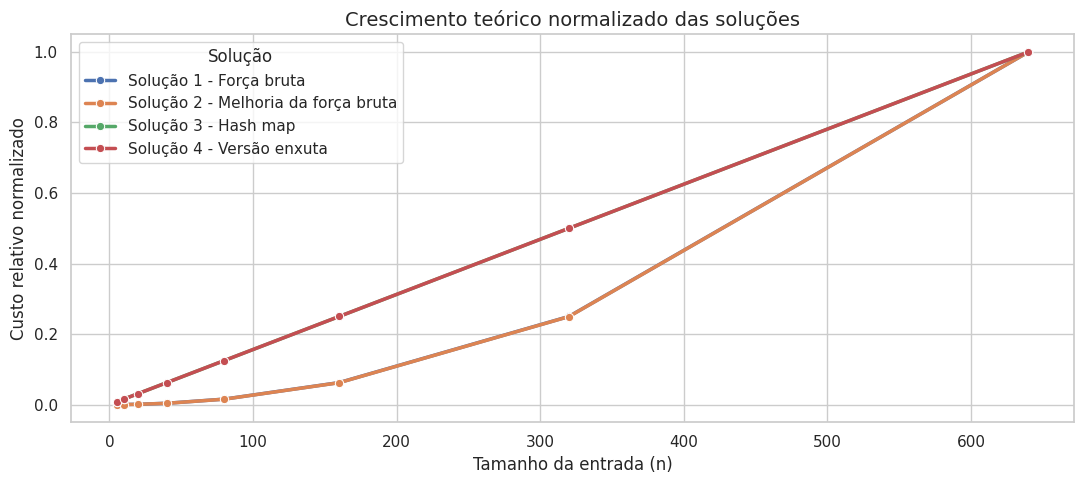

In [12]:
plotar_curva_complexidade(
    df_complexidade,
    x="tamanho_entrada",
    y="custo_normalizado",
    hue="solucao",
    titulo="Crescimento teórico normalizado das soluções",
    xlabel="Tamanho da entrada (n)",
    ylabel="Custo relativo normalizado",
)


In [13]:
tamanhos_benchmark = [10, 50, 100, 200, 400, 800]
repeticoes_benchmark = 5

resultados_benchmark = pd.concat(
    [
        executar_benchmark(
            two_sum_brute_force,
            "Solução 1 - Força bruta",
            tamanhos_benchmark,
            repeticoes_benchmark,
        ),
        executar_benchmark(
            two_sum_brute_force_improved,
            "Solução 2 - Melhoria da força bruta",
            tamanhos_benchmark,
            repeticoes_benchmark,
        ),
        executar_benchmark(
            two_sum_hash_map,
            "Solução 3 - Hash map",
            tamanhos_benchmark,
            repeticoes_benchmark,
        ),
        executar_benchmark(
            Solution().twoSum,
            "Solução 4 - Versão enxuta",
            tamanhos_benchmark,
            repeticoes_benchmark,
        ),
    ],
    ignore_index=True,
)

resumo_benchmark = (
    resultados_benchmark.groupby(["solucao", "tamanho_entrada"], as_index=False)
    .agg(
        tempo_medio_s=("tempo_medio_s", "mean"),
        tempo_desvio_s=("tempo_desvio_s", "mean"),
        tempo_medio_ms=("tempo_medio_ms", "mean"),
        tempo_desvio_ms=("tempo_desvio_ms", "mean"),
    )
    .sort_values(["solucao", "tamanho_entrada"])
)

resumo_benchmark


,solucao,tamanho_entrada,tempo_medio_s,tempo_desvio_s,tempo_medio_ms,tempo_desvio_ms
0,Solução 1 - Força bruta,10,0.000004,6.870918e-07,0.003739,0.000687
1,Solução 1 - Força bruta,50,0.000033,6.798052e-07,0.033135,0.000680
2,Solução 1 - Força bruta,100,0.000142,3.174646e-06,0.142244,0.003175
3,Solução 1 - Força bruta,200,0.000347,5.529867e-06,0.346656,0.005530
4,Solução 1 - Força bruta,400,0.000318,9.405692e-06,0.318351,0.009406
5,Solução 1 - Força bruta,800,0.001033,1.058067e-05,1.033483,0.010581
6,Solução 2 - Melhoria da força bruta,10,0.000002,5.365058e-07,0.002071,0.000537
7,Solução 2 - Melhoria da força bruta,50,0.000019,7.062720e-07,0.018576,0.000706
8,Solução 2 - Melhoria da força bruta,100,0.000076,4.318546e-06,0.076097,0.004319
9,Solução 2 - Melhoria da força bruta,200,0.000214,4.851339e-06,0.213811,0.004851


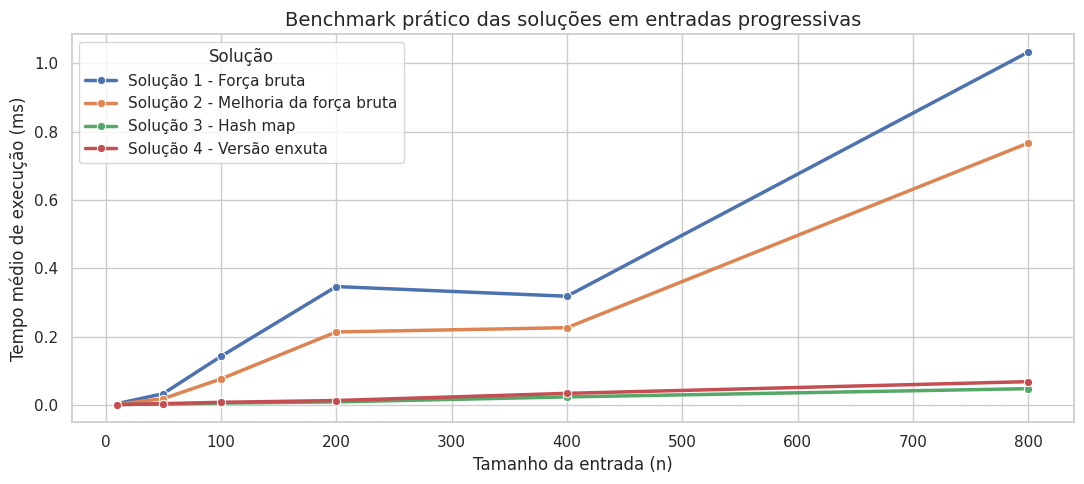

In [14]:
plotar_curva_complexidade(
    resumo_benchmark,
    x="tamanho_entrada",
    y="tempo_medio_ms",
    hue="solucao",
    titulo="Benchmark prático das soluções em entradas progressivas",
    xlabel="Tamanho da entrada (n)",
    ylabel="Tempo médio de execução (ms)",
)


In [15]:
tabela_speedup = (
    resumo_benchmark.pivot(
        index="tamanho_entrada",
        columns="solucao",
        values="tempo_medio_ms",
    )
    .assign(
        **{
            "Speedup da solução 3 sobre a 1": lambda df: df["Solução 1 - Força bruta"]
            / df["Solução 3 - Hash map"],
            "Speedup da solução 3 sobre a 2": lambda df: df["Solução 2 - Melhoria da força bruta"]
            / df["Solução 3 - Hash map"],
        }
    )
)

tabela_speedup


solucao,Solução 1 - Força bruta,Solução 2 - Melhoria da força bruta,Solução 3 - Hash map,Solução 4 - Versão enxuta,Speedup da solução 3 sobre a 1,Speedup da solução 3 sobre a 2
tamanho_entrada,,,,,,
10,0.003739,0.002071,0.001341,0.001074,2.787504,1.543841
50,0.033135,0.018576,0.002636,0.003937,12.569077,7.046431
100,0.142244,0.076097,0.005633,0.007854,25.253702,13.510173
200,0.346656,0.213811,0.008986,0.013105,38.576528,23.793283
400,0.318351,0.226305,0.023611,0.034053,13.483033,9.584663
800,1.033483,0.767037,0.047735,0.068346,21.650329,16.068578


## Conclusão

O `Two Sum` é um ótimo problema para estudar a evolução entre pensar
primeiro em uma solução simples, depois reduzir redundâncias e por fim
chegar à estratégia mais prática.

- A solução 1 é valiosa para entender o problema, mas sofre com o custo
  quadrático.
- A solução 2 melhora a implementação sem mudar a classe assintótica.
- A solução 3 é a resposta principal na prática: simples, rápida e com
  custo linear médio.
- A solução 4 mostra como transformar a ideia ótima em uma versão curta e
  pronta para envio ao LeetCode.

A principal lição é separar duas perguntas diferentes: **entender** o
problema e **submeter** uma solução eficiente. O hash map cumpre as duas
funções muito bem.
